# ASAP7 cross-session DMD/depth coherence

This notebook takes the single-session coherence logic from the earlier frequency notebook and runs it across sessions/mice.

Primary outputs:

1. **DMD population coherence** between DMD1 and DMD2 for each session.
2. **Band summaries** of DMD1/DMD2 coherence across sessions.
3. Optional **ROI-pair coherence summaries** for within-DMD1, within-DMD2, and between-DMD ROI pairs.
4. Matched familiar/novel/novel+ summaries across mice.

Interpretation note: if DMD1 and DMD2 are fixed to different depths, this notebook analyzes **DMD/depth-associated coherence**, not a clean depth-only effect.

In [1]:
import os
import sys
import glob
import json
import h5py
import warnings
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

from vip_slap2_analysis.io.session_registry import VIPSessionRegistry
from vip_slap2_analysis.utils.utils import save_figure

import matplotlib.pyplot as plt
from IPython.display import display, HTML

display(HTML("<style>.container { width:100% !important; }</style>"))
warnings.filterwarnings("default")

In [2]:
%matplotlib inline

In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
today_str = datetime.today().strftime('%Y-%m-%d')

BASE_PATH = Path(r'\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics')
SAVE_PATH = Path(r'C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots')

TARGET_MICE = [
    826031,
    826032,
]

PARADIGMS = ["change_detection_passive"]
EXCLUDE_SESSION_TYPES = ["expression_check", "volume_imaging"]

# Voltage extraction writes files like:
#     voltage_session_traces_dff_robust_f0_trial.h5
# This variant controls the filename suffix. The plotted dataset is SIGNAL below.
TRACE_VARIANT = "dff_robust_f0_trial"
SIGNAL = "dff"  # one of: "raw_f", "f0", "dff"

# Optional direct override. Leave as None to resolve from asset.derived_dir / "voltage".
SESSION_TRACE_H5 = None

In [5]:
registry = VIPSessionRegistry.from_basepath(BASE_PATH)

process_df = registry.sessions(
    subject_ids=TARGET_MICE,
    exclude_session_types=EXCLUDE_SESSION_TYPES,
    paradigms=PARADIGMS,
)

assets = [registry.resolve_assets(row) for _, row in process_df.iterrows()]

print(f"Found {len(assets)} candidate sessions.")
display(process_df)

Found 19 candidate sessions.


,session_id,subject_id,session_#,session_date,indicator1,indicator2,dmd1_depth,dmd2_depth,paradigm,session_type,...,instrument_id,camera_type,has raster ROI?,has integration roi?,behavior_rig,quality,flags,session_dir,purpose,notes
0,826031_2026-01-30_15-04-02,826031,2,2026-01-30,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
1,826031_2026-02-01_11-01-50,826031,3,2026-02-01,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
2,826031_2026-02-02_10-23-53,826031,4,2026-02-02,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
3,826031_2026-02-03_14-21-45,826031,5,2026-02-03,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
4,826031_2026-02-04_12-15-34,826031,6,2026-02-04,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
5,826031_2026-02-05_09-28-56,826031,7,2026-02-05,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
6,826031_2026-02-06_10-21-20,826031,8,2026-02-06,ASAP7y,NaN,50,250,change_detection_passive,familiar,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
7,826031_2026-02-10_10-48-51,826031,9,2026-02-10,ASAP7y,NaN,50,250,change_detection_passive,novel,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
8,826031_2026-02-11_12-42-21,826031,10,2026-02-11,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN
9,826031_2026-02-12_07-43-37,826031,11,2026-02-12,ASAP7y,NaN,50,250,change_detection_passive,novel+,...,SLAP2_1,spinnaker,yes,yes,VCO.1,good,NaN,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,NaN,NaN


## Analysis configuration

In [6]:
# ---------------------------------------------------------------------
# Low/mid-frequency loading
# ---------------------------------------------------------------------
LOWFREQ_TARGET_FS_HZ = 500.0
LOWFREQ_VALID_ROIS_ONLY = True
LOWFREQ_MAX_SECONDS = None  # e.g. 600 for a smoke test; None for full session
TIMEBASE_GAP_FACTOR = 5.0
MIN_SEGMENT_SEC = 2.0
USE_LOW_FREQ_CACHE = True
FORCE_RELOAD_LOW_FREQ_CACHE = False

# ---------------------------------------------------------------------
# DMD population coherence
# ---------------------------------------------------------------------
POPULATION_MODE = "roi_robust_z_mean"  # "raw_mean", "roi_z_mean", or "roi_robust_z_mean"
COH_WINDOW_SEC = 128.0
COH_OVERLAP_FRAC = 0.5
COH_DETREND = "constant"

# Keep bands interpretable for this first-pass cross-session comparison.
COHERENCE_BANDS = {
    "0.5-4Hz": (0.5, 4.0),
    "4-15Hz": (4.0, 15.0),
    "15-40Hz": (15.0, 40.0),
    "40-100Hz": (40.0, 100.0),
    "100-200Hz": (100.0, 200.0),
}

# ---------------------------------------------------------------------
# Optional ROI-pair coherence by class
# ---------------------------------------------------------------------
RUN_ROI_PAIR_COHERENCE = True
PAIR_COH_INPUT_MODE = "demean"
PAIR_COH_MAX_PAIRS_PER_CLASS = None  # set e.g. 100 for quick smoke testing
PAIR_COH_RANDOM_SEED = 0

# ---------------------------------------------------------------------
# Matching across mice/session types
# ---------------------------------------------------------------------
MATCH_SESSION_TYPES_ACROSS_MICE = True
MIN_MICE_PER_SESSION_TYPE = len(TARGET_MICE)

# Outputs
OUT_DIR = SAVE_PATH / "asap7_cross_session_dmd_coherence"
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("Output directory:", OUT_DIR)

Output directory: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence


## Helper functions

In [7]:
from scipy import signal as scipy_signal

try:
    from tqdm.auto import tqdm
except Exception:
    tqdm = None


def _maybe_get(obj, name, default=None):
    """Safely get attr or dict key from an asset-like object."""
    if hasattr(obj, name):
        return getattr(obj, name)
    if isinstance(obj, dict) and name in obj:
        return obj[name]
    return default


def resolve_voltage_h5(asset, trace_variant=TRACE_VARIANT, session_trace_h5=SESSION_TRACE_H5):
    """
    Resolve the session-long voltage trace H5 path.

    Expected filename:
        voltage_session_traces_{TRACE_VARIANT}.h5

    Uses SESSION_TRACE_H5 if provided; otherwise tries asset.derived_dir / "voltage".
    """
    if session_trace_h5 is not None:
        path = Path(session_trace_h5)
        if not path.exists():
            raise FileNotFoundError(path)
        return path

    derived_dir = _maybe_get(asset, "derived_dir", None)
    if derived_dir is None:
        raise ValueError("Could not find asset.derived_dir. Set SESSION_TRACE_H5 manually.")

    derived_dir = Path(derived_dir)
    candidates = [
        derived_dir / "voltage" / f"voltage_session_traces_{trace_variant}.h5",
        derived_dir / f"voltage_session_traces_{trace_variant}.h5",
    ]

    for path in candidates:
        if path.exists():
            return path

    print("Tried:")
    for path in candidates:
        print("  ", path)
    raise FileNotFoundError("Could not resolve voltage session trace H5.")


def _decode_roi_ids(roi_ids):
    """Decode ROI ids from HDF5 bytes/strings into a clean numpy string array."""
    out = []
    for x in roi_ids:
        if isinstance(x, bytes):
            out.append(x.decode("utf-8"))
        else:
            out.append(str(x))
    return np.asarray(out, dtype=str)


def _get_dmd_keys(h5):
    """Return sorted DMD group names."""
    return sorted([k for k in h5.keys() if k.upper().startswith("DMD")])


def _estimate_fs_from_timebase(t, n_check=200_000):
    """Estimate sampling rate from the start of a timebase vector."""
    n = min(int(n_check), len(t))
    tt = np.asarray(t[:n], dtype=np.float64)
    dt = np.diff(tt)
    dt = dt[np.isfinite(dt) & (dt > 0)]
    if dt.size == 0:
        raise ValueError("Could not estimate sampling rate from timebase.")
    median_dt = float(np.nanmedian(dt))
    fs = 1.0 / median_dt
    return fs, median_dt


def _infer_trace_layout(y_ds, t_ds):
    """
    Infer whether the trace dataset is ROI x time or time x ROI.

    Returns
    -------
    layout : str
        Either "roi_time" or "time_roi".
    n_rois : int
    n_time : int
    """
    n_time = int(t_ds.shape[0])

    if y_ds.shape[-1] == n_time:
        return "roi_time", int(y_ds.shape[0]), n_time
    if y_ds.shape[0] == n_time:
        return "time_roi", int(y_ds.shape[1]), n_time

    raise ValueError(
        f"Could not infer trace layout. Trace shape={y_ds.shape}, "
        f"timebase length={n_time}"
    )


def _read_roi_trace(y_ds, roi_index, layout, n_time_use=None):
    """Read one ROI trace from an HDF5 dataset."""
    if n_time_use is None:
        n_time_use = y_ds.shape[-1] if layout == "roi_time" else y_ds.shape[0]

    if layout == "roi_time":
        y = np.asarray(y_ds[roi_index, :n_time_use], dtype=np.float32)
    elif layout == "time_roi":
        y = np.asarray(y_ds[:n_time_use, roi_index], dtype=np.float32)
    else:
        raise ValueError(f"Unknown layout: {layout}")

    return y


def _interp_nans_1d(y):
    """Interpolate NaNs/infs in a 1D trace."""
    y = np.asarray(y, dtype=np.float32)
    finite = np.isfinite(y)

    if finite.all():
        return y
    if finite.sum() < 2:
        return np.zeros_like(y, dtype=np.float32)

    x = np.arange(y.size)
    y = y.copy()
    y[~finite] = np.interp(x[~finite], x[finite], y[finite]).astype(np.float32)
    return y


def _find_timebase_segments(t, fs_hz, gap_factor=5.0, min_segment_sec=2.0):
    """
    Find contiguous sample segments from a timebase.

    Boundaries are detected when dt is much larger than the nominal sampling interval.
    """
    t = np.asarray(t, dtype=np.float64)
    dt = np.diff(t)

    nominal_dt = 1.0 / float(fs_hz)
    gap_threshold = gap_factor * nominal_dt
    gap_locs = np.where(dt > gap_threshold)[0]

    starts = np.r_[0, gap_locs + 1]
    stops = np.r_[gap_locs + 1, len(t)]

    min_samples = max(2, int(np.ceil(min_segment_sec * fs_hz)))
    keep = (stops - starts) >= min_samples
    starts = starts[keep]
    stops = stops[keep]

    segments = np.column_stack([starts, stops]).astype(np.int64)
    audit = {
        "nominal_dt_sec": nominal_dt,
        "gap_threshold_sec": gap_threshold,
        "n_detected_gaps": int(len(gap_locs)),
        "n_kept_segments": int(len(segments)),
        "min_segment_sec": float(min_segment_sec),
        "max_dt_sec": float(np.nanmax(dt)) if dt.size else np.nan,
        "median_dt_sec": float(np.nanmedian(dt)) if dt.size else np.nan,
    }
    return segments, audit


def robust_zscore_rows(X, eps=1e-6):
    """Median/MAD z-score each ROI row. Useful before averaging ROIs into a DMD population signal."""
    X = np.asarray(X, dtype=np.float32)
    med = np.nanmedian(X, axis=1, keepdims=True)
    mad = np.nanmedian(np.abs(X - med), axis=1, keepdims=True)
    scale = 1.4826 * mad
    scale = np.where(np.isfinite(scale) & (scale > eps), scale, np.nanstd(X, axis=1, keepdims=True))
    scale = np.where(np.isfinite(scale) & (scale > eps), scale, 1.0)
    return ((X - med) / scale).astype(np.float32)


def standardize_rows(X, eps=1e-8):
    """Mean/std standardize rows for correlation/coherence work."""
    X = np.asarray(X, dtype=np.float32)
    mu = np.nanmean(X, axis=1, keepdims=True)
    sd = np.nanstd(X, axis=1, keepdims=True)
    sd = np.where(np.isfinite(sd) & (sd > eps), sd, 1.0)
    Z = (X - mu) / sd
    Z[~np.isfinite(Z)] = 0
    return Z.astype(np.float32)


def preprocess_X_for_psd(X, mode="robust_z"):
    """Preprocess ROI x time matrix before spectral estimates."""
    if mode == "none":
        return np.asarray(X, dtype=np.float32)
    if mode == "demean":
        X = np.asarray(X, dtype=np.float32)
        return (X - np.nanmean(X, axis=1, keepdims=True)).astype(np.float32)
    if mode == "zscore":
        return standardize_rows(X)
    if mode == "robust_z":
        return robust_zscore_rows(X)
    raise ValueError(f"Unknown mode: {mode}")


def _resample_poly_1d(y, down):
    """Anti-aliased integer downsampling using scipy.signal.resample_poly."""
    y = _interp_nans_1d(y)
    if down <= 1:
        return y.astype(np.float32, copy=False)
    try:
        y_low = scipy_signal.resample_poly(
            y, up=1, down=down, window=("kaiser", 8.6), padtype="line"
        )
    except TypeError:
        y_low = scipy_signal.resample_poly(y, up=1, down=down, window=("kaiser", 8.6))
    return y_low.astype(np.float32, copy=False)

In [8]:
def _lowfreq_cache_path(trace_h5, signal, target_fs_hz, valid_rois_only, max_seconds):
    max_tag = "full" if max_seconds is None else f"first{int(max_seconds)}s"
    valid_tag = "validrois" if valid_rois_only else "allrois"
    fname = (
        f"{Path(trace_h5).stem}"
        f"__{signal}"
        f"__lowfreq_fs{target_fs_hz:g}"
        f"__{valid_tag}"
        f"__{max_tag}.npz"
    )
    return Path(trace_h5).with_name(fname)


def _save_lowfreq_cache(lf, cache_path):
    """Save low-frequency session dict to NPZ."""
    save_dict = {
        "trace_h5": str(lf["trace_h5"]),
        "signal": str(lf["signal"]),
        "target_fs_hz": float(lf["target_fs_hz"]),
        "dmd_keys": np.asarray(list(lf["dmd"].keys()), dtype=str),
    }
    for dmd, d in lf["dmd"].items():
        save_dict[f"{dmd}_X"] = d["X"]
        save_dict[f"{dmd}_time_sec"] = d["time_sec"]
        save_dict[f"{dmd}_segments_sample"] = d["segments_sample"]
        save_dict[f"{dmd}_segments_low"] = d["segments_low"]
        save_dict[f"{dmd}_roi_ids"] = np.asarray(d["roi_ids"], dtype=str)
        save_dict[f"{dmd}_source_roi_indices"] = np.asarray(d["source_roi_indices"], dtype=np.int64)
        save_dict[f"{dmd}_fs_source_hz"] = float(d["fs_source_hz"])
        save_dict[f"{dmd}_fs_low_hz"] = float(d["fs_low_hz"])
        save_dict[f"{dmd}_decimation"] = int(d["decimation"])
        save_dict[f"{dmd}_timebase_audit_keys"] = np.asarray(list(d["timebase_audit"].keys()), dtype=str)
        save_dict[f"{dmd}_timebase_audit_values"] = np.asarray(list(d["timebase_audit"].values()), dtype=float)
    np.savez(cache_path, **save_dict)


def _load_lowfreq_cache(cache_path):
    """Load low-frequency session dict from NPZ."""
    with np.load(cache_path, allow_pickle=False) as z:
        dmd_keys = [str(x) for x in z["dmd_keys"]]
        lf = {
            "trace_h5": Path(str(z["trace_h5"].item())),
            "signal": str(z["signal"].item()),
            "target_fs_hz": float(z["target_fs_hz"]),
            "dmd": {},
            "cache_path": Path(cache_path),
        }
        for dmd in dmd_keys:
            audit_keys = [str(x) for x in z[f"{dmd}_timebase_audit_keys"]]
            audit_vals = [float(x) for x in z[f"{dmd}_timebase_audit_values"]]
            audit = dict(zip(audit_keys, audit_vals))
            lf["dmd"][dmd] = {
                "X": z[f"{dmd}_X"].astype(np.float32, copy=False),
                "time_sec": z[f"{dmd}_time_sec"].astype(np.float64, copy=False),
                "segments_sample": z[f"{dmd}_segments_sample"].astype(np.int64, copy=False),
                "segments_low": z[f"{dmd}_segments_low"].astype(np.int64, copy=False),
                "roi_ids": z[f"{dmd}_roi_ids"].astype(str),
                "source_roi_indices": z[f"{dmd}_source_roi_indices"].astype(np.int64, copy=False),
                "fs_source_hz": float(z[f"{dmd}_fs_source_hz"]),
                "fs_low_hz": float(z[f"{dmd}_fs_low_hz"]),
                "decimation": int(z[f"{dmd}_decimation"]),
                "timebase_audit": audit,
            }
    return lf


def load_lowfreq_voltage_session(
    trace_h5,
    signal="dff",
    target_fs_hz=500.0,
    valid_rois_only=True,
    max_seconds=None,
    gap_factor=5.0,
    min_segment_sec=2.0,
    use_cache=True,
    force_reload=False,
):
    """
    Load a session-long voltage H5 into a low-frequency, ROI x time representation.

    This reads each ROI one at a time, downsamples each contiguous segment separately,
    and caches the result beside the H5. The cache is intentionally trace-variant and
    max-duration specific.
    """
    trace_h5 = Path(trace_h5)
    cache_path = _lowfreq_cache_path(
        trace_h5=trace_h5,
        signal=signal,
        target_fs_hz=target_fs_hz,
        valid_rois_only=valid_rois_only,
        max_seconds=max_seconds,
    )
    if use_cache and cache_path.exists() and not force_reload:
        return _load_lowfreq_cache(cache_path)

    lf = {
        "trace_h5": trace_h5,
        "signal": signal,
        "target_fs_hz": float(target_fs_hz),
        "dmd": {},
    }

    with h5py.File(trace_h5, "r") as h5:
        dmd_keys = _get_dmd_keys(h5)
        for dmd in dmd_keys:
            g = h5[dmd]
            if signal not in g:
                print(f"Skipping {dmd}: '{signal}' not found. Available keys: {list(g.keys())}")
                continue

            y_ds = g[signal]
            t_ds = g["timebase_sec"]
            layout, n_rois, n_time = _infer_trace_layout(y_ds, t_ds)

            fs_source, source_dt = _estimate_fs_from_timebase(t_ds)
            t_full = np.asarray(t_ds[:], dtype=np.float64)

            if max_seconds is not None:
                stop_time = float(t_full[0]) + float(max_seconds)
                n_time_use = int(np.searchsorted(t_full, stop_time, side="right"))
                n_time_use = max(2, min(n_time_use, n_time))
            else:
                n_time_use = n_time

            t = t_full[:n_time_use]
            fs_source, source_dt = _estimate_fs_from_timebase(t)
            segments_sample, audit = _find_timebase_segments(
                t, fs_hz=fs_source, gap_factor=gap_factor, min_segment_sec=min_segment_sec
            )

            down = max(1, int(round(fs_source / float(target_fs_hz))))
            fs_low = fs_source / down

            if "roi_ids" in g:
                roi_ids_all = _decode_roi_ids(g["roi_ids"][:])
            else:
                roi_ids_all = np.asarray([f"roi_{i}" for i in range(n_rois)], dtype=str)

            if valid_rois_only and "valid_rois_mask" in g:
                valid = np.asarray(g["valid_rois_mask"][:], dtype=bool)
            else:
                valid = np.ones(n_rois, dtype=bool)

            roi_indices = np.where(valid)[0]
            roi_ids = roi_ids_all[roi_indices]
            X_rows = []

            iterator = roi_indices
            if tqdm is not None:
                iterator = tqdm(roi_indices, desc=f"Loading {dmd}", leave=False)

            for roi_idx in iterator:
                y = _read_roi_trace(y_ds, int(roi_idx), layout, n_time_use=n_time_use)
                low_segments = []
                low_cursor = 0
                y_low_parts = []
                for s0, s1 in segments_sample:
                    y_seg = y[int(s0):int(s1)]
                    y_low = _resample_poly_1d(y_seg, down=down)
                    if y_low.size < 2:
                        continue
                    y_low_parts.append(y_low)
                    low_segments.append((low_cursor, low_cursor + len(y_low)))
                    low_cursor += len(y_low)
                X_rows.append(np.concatenate(y_low_parts).astype(np.float32))

            if len(X_rows) == 0:
                print(f"Skipping {dmd}: no valid ROI traces loaded.")
                continue

            # Force equal length in case resampling produced one-sample differences.
            min_len = min(len(x) for x in X_rows)
            X = np.vstack([x[:min_len] for x in X_rows]).astype(np.float32)

            t_low_parts = []
            for s0, s1 in segments_sample:
                tt = t[int(s0):int(s1)]
                # Construct time vector with the same length as the resampled segment.
                n_low = len(_resample_poly_1d(tt.astype(np.float32), down=down))
                if n_low < 2:
                    continue
                t_low_parts.append(np.linspace(float(tt[0]), float(tt[-1]), n_low, dtype=np.float64))
            t_low = np.concatenate(t_low_parts)[:min_len]

            # Recompute low segments from the generated time vector, or use accumulated approximate boundaries.
            segments_low, _ = _find_timebase_segments(
                t_low, fs_hz=fs_low, gap_factor=gap_factor, min_segment_sec=min_segment_sec
            )

            lf["dmd"][dmd] = {
                "X": X,
                "time_sec": t_low,
                "segments_sample": segments_sample,
                "segments_low": segments_low,
                "roi_ids": roi_ids,
                "source_roi_indices": roi_indices.astype(np.int64),
                "fs_source_hz": float(fs_source),
                "fs_low_hz": float(fs_low),
                "decimation": int(down),
                "timebase_audit": audit,
            }

            print(
                f"{dmd}: loaded {X.shape[0]} ROIs x {X.shape[1]} samples; "
                f"fs {fs_source:.1f} -> {fs_low:.1f} Hz; duration {X.shape[1] / fs_low:.1f} s"
            )

    if use_cache:
        _save_lowfreq_cache(lf, cache_path)
        lf["cache_path"] = cache_path
        print("Saved cache:", cache_path)
    return lf

In [9]:
PSD_EPS = 1e-20


def _segments_to_int(segments, n_time):
    if segments is None:
        return np.asarray([[0, n_time]], dtype=np.int64)
    seg = np.asarray(segments, dtype=np.int64)
    seg[:, 0] = np.clip(seg[:, 0], 0, n_time)
    seg[:, 1] = np.clip(seg[:, 1], 0, n_time)
    seg = seg[(seg[:, 1] - seg[:, 0]) > 1]
    return seg


def compute_segmented_cross_spectrum(
    x,
    y,
    fs_hz,
    segments=None,
    window_sec=128.0,
    overlap_frac=0.5,
    detrend="constant",
):
    """Compute weighted-average Welch/CSD coherence across contiguous segments."""
    x = _interp_nans_1d(np.asarray(x, dtype=np.float32))
    y = _interp_nans_1d(np.asarray(y, dtype=np.float32))
    if x.shape != y.shape:
        raise ValueError("x and y must have the same length.")

    n_time = len(x)
    fs_hz = float(fs_hz)
    segments = _segments_to_int(segments, n_time)

    requested_nperseg = max(8, int(round(window_sec * fs_hz)))
    seg_lengths = segments[:, 1] - segments[:, 0]
    usable = seg_lengths >= requested_nperseg

    if not np.any(usable):
        longest = int(np.max(seg_lengths))
        nperseg = max(8, longest)
        usable = seg_lengths >= nperseg
        print(
            f"No segment was long enough for requested coherence window "
            f"({requested_nperseg / fs_hz:.1f} s). Using {nperseg / fs_hz:.1f} s."
        )
    else:
        nperseg = requested_nperseg

    noverlap = int(round(overlap_frac * nperseg))
    noverlap = min(noverlap, nperseg - 1)
    step = max(1, nperseg - noverlap)

    Sxx_accum = None
    Syy_accum = None
    Sxy_accum = None
    f_ref = None
    weight_accum = 0.0
    used_segments = []

    for start, stop in segments[usable]:
        start, stop = int(start), int(stop)
        n = stop - start
        if n < nperseg:
            continue
        xs = x[start:stop]
        ys = y[start:stop]

        f, Sxx = scipy_signal.welch(
            xs, fs=fs_hz, window="hann", nperseg=nperseg,
            noverlap=noverlap, detrend=detrend, return_onesided=True, scaling="density"
        )
        f2, Syy = scipy_signal.welch(
            ys, fs=fs_hz, window="hann", nperseg=nperseg,
            noverlap=noverlap, detrend=detrend, return_onesided=True, scaling="density"
        )
        f3, Sxy = scipy_signal.csd(
            xs, ys, fs=fs_hz, window="hann", nperseg=nperseg,
            noverlap=noverlap, detrend=detrend, return_onesided=True, scaling="density"
        )
        if not (np.allclose(f, f2) and np.allclose(f, f3)):
            raise RuntimeError("Frequency vectors differed across spectral estimates.")

        n_windows = 1 + max(0, (n - nperseg) // step)
        weight = float(n_windows)
        if Sxx_accum is None:
            Sxx_accum = weight * Sxx
            Syy_accum = weight * Syy
            Sxy_accum = weight * Sxy
            f_ref = f
        else:
            Sxx_accum += weight * Sxx
            Syy_accum += weight * Syy
            Sxy_accum += weight * Sxy
        weight_accum += weight
        used_segments.append((start, stop, n_windows))

    if Sxx_accum is None:
        raise RuntimeError("No usable segments for cross-spectrum computation.")

    Sxx = Sxx_accum / weight_accum
    Syy = Syy_accum / weight_accum
    Sxy = Sxy_accum / weight_accum
    coherence = (np.abs(Sxy) ** 2) / np.maximum(Sxx * Syy, PSD_EPS)
    phase_rad = np.angle(Sxy)
    meta = {
        "fs_hz": fs_hz,
        "requested_window_sec": float(window_sec),
        "actual_window_sec": float(nperseg / fs_hz),
        "freq_resolution_hz": float(f_ref[1] - f_ref[0]) if len(f_ref) > 1 else np.nan,
        "nperseg": int(nperseg),
        "noverlap": int(noverlap),
        "n_input_segments": int(len(segments)),
        "n_used_segments": int(len(used_segments)),
        "total_windows": int(weight_accum),
    }
    return {"f": f_ref, "Sxx": Sxx, "Syy": Syy, "Sxy": Sxy, "coherence": coherence, "phase_rad": phase_rad, "meta": meta}


def summarize_spectrum_by_bands(f, y, bands):
    """Return long-format band summaries for a frequency-indexed vector."""
    rows = []
    f = np.asarray(f, dtype=float)
    y = np.asarray(y, dtype=float)
    for band_name, (f0, f1) in bands.items():
        m = (f >= f0) & (f < f1) & np.isfinite(y)
        if np.any(m):
            rows.append({
                "band": band_name,
                "fmin_hz": float(f0),
                "fmax_hz": float(f1),
                "n_freq": int(np.sum(m)),
                "mean": float(np.nanmean(y[m])),
                "median": float(np.nanmedian(y[m])),
                "max": float(np.nanmax(y[m])),
            })
        else:
            rows.append({
                "band": band_name,
                "fmin_hz": float(f0),
                "fmax_hz": float(f1),
                "n_freq": 0,
                "mean": np.nan,
                "median": np.nan,
                "max": np.nan,
            })
    return pd.DataFrame(rows)


def make_dmd_population_signal(X, mode="roi_robust_z_mean"):
    """Create one population trace per DMD."""
    if mode == "raw_mean":
        return np.nanmean(X, axis=0).astype(np.float32)
    if mode == "roi_z_mean":
        return np.nanmean(standardize_rows(X), axis=0).astype(np.float32)
    if mode == "roi_robust_z_mean":
        return np.nanmean(robust_zscore_rows(X), axis=0).astype(np.float32)
    raise ValueError(f"Unknown population mode: {mode}")


def align_two_1d_series(t1, y1, t2, y2, fs_hint=None, tolerance_sec=None):
    """Align two traces to a common timebase by truncation if possible, interpolation otherwise."""
    t1 = np.asarray(t1, dtype=float)
    t2 = np.asarray(t2, dtype=float)
    y1 = np.asarray(y1, dtype=np.float32)
    y2 = np.asarray(y2, dtype=np.float32)

    n = min(len(t1), len(t2), len(y1), len(y2))
    if tolerance_sec is None:
        fs_guess = fs_hint if fs_hint is not None else 1.0 / np.nanmedian(np.diff(t1[:min(len(t1), 10000)]))
        tolerance_sec = 0.5 / float(fs_guess)

    if len(t1) >= n and len(t2) >= n and np.allclose(t1[:n], t2[:n], rtol=0, atol=tolerance_sec):
        return t1[:n], y1[:n], y2[:n], "truncate"

    t0 = max(float(t1[0]), float(t2[0]))
    t_stop = min(float(t1[-1]), float(t2[-1]))
    if t_stop <= t0:
        raise ValueError("DMD timebases do not overlap.")
    if fs_hint is None:
        fs_hint = min(1.0 / np.nanmedian(np.diff(t1)), 1.0 / np.nanmedian(np.diff(t2)))
    dt = 1.0 / float(fs_hint)
    t_common = np.arange(t0, t_stop, dt, dtype=np.float64)
    y1c = np.interp(t_common, t1, y1).astype(np.float32)
    y2c = np.interp(t_common, t2, y2).astype(np.float32)
    return t_common, y1c, y2c, "interp"

In [10]:
# ---------------------------------------------------------------------
# Session metadata parsing
# ---------------------------------------------------------------------
# Keep this permissive because the registry columns can evolve. Adjust the
# candidate column names here if the session type is stored somewhere specific.

SESSION_TYPE_ALIASES = {
    "familiar": "familiar",
    "fam": "familiar",
    "familiar_images": "familiar",
    "novel": "novel",
    "novel_images": "novel",
    "novel+": "novel_plus",
    "novel_plus": "novel_plus",
    "novelplus": "novel_plus",
    "novel_plus_images": "novel_plus",
}
SESSION_TYPE_ORDER = ["familiar", "novel", "novel_plus"]

# Use this if the H5/registry does not expose depth metadata. This reflects the
# current design you described, but keep it explicit so DMD/depth confounds are visible.
DMD_DEPTH_UM_OVERRIDE = {
    "DMD1": 50,
    "DMD2": 250,
}


def normalize_session_type(x):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "unknown"
    s = str(x).strip().lower().replace("-", "_").replace(" ", "_")
    if s in SESSION_TYPE_ALIASES:
        return SESSION_TYPE_ALIASES[s]
    # permissive substring handling
    if "novel" in s and ("plus" in s or "+" in s):
        return "novel_plus"
    if "novel" in s:
        return "novel"
    if "familiar" in s or "fam" in s:
        return "familiar"
    return s if s else "unknown"


def infer_session_type(row=None, asset=None):
    candidates = [
        "session_type", "experiment_type", "experience_level", "image_set", "stimulus_set",
        "stimulus_name", "session_name", "session", "notes", "path", "data_path",
    ]
    if row is not None:
        for c in candidates:
            if hasattr(row, "index") and c in row.index:
                val = row[c]
                norm = normalize_session_type(val)
                if norm != "unknown":
                    return norm
    # Fall back to scanning asset paths/strings.
    pieces = []
    if asset is not None:
        for name in ["session_dir", "derived_dir", "raw_dir", "path"]:
            val = _maybe_get(asset, name, None)
            if val is not None:
                pieces.append(str(val))
    if row is not None:
        pieces.append(" ".join([str(v) for v in getattr(row, "values", [])]))
    return normalize_session_type(" ".join(pieces))


def infer_mouse_id(row=None, asset=None):
    for c in ["subject_id", "mouse_id", "animal_id", "subject", "mouse"]:
        if row is not None and hasattr(row, "index") and c in row.index:
            val = row[c]
            if pd.notna(val):
                try:
                    return int(val)
                except Exception:
                    return str(val)
    for name in ["subject_id", "mouse_id", "subject"]:
        val = _maybe_get(asset, name, None)
        if val is not None:
            try:
                return int(val)
            except Exception:
                return str(val)
    return "unknown"


def infer_session_label(row=None, asset=None, fallback_index=None):
    for c in ["session_id", "session_name", "session", "ophys_session_id", "date", "datetime"]:
        if row is not None and hasattr(row, "index") and c in row.index:
            val = row[c]
            if pd.notna(val):
                return str(val)
    for name in ["session_id", "session_name", "session_dir"]:
        val = _maybe_get(asset, name, None)
        if val is not None:
            return Path(str(val)).name
    return f"session_{fallback_index}" if fallback_index is not None else "unknown_session"


def infer_session_date(row=None, asset=None):
    for c in ["date", "session_date", "datetime", "start_time", "session_start_time"]:
        if row is not None and hasattr(row, "index") and c in row.index:
            val = row[c]
            try:
                return pd.to_datetime(val)
            except Exception:
                pass
    label = infer_session_label(row, asset)
    # Try to parse YYYY-MM-DD from folder/session label.
    m = pd.Series([label]).str.extract(r"(20\d{2}[-_]\d{2}[-_]\d{2})").iloc[0, 0]
    if isinstance(m, str):
        try:
            return pd.to_datetime(m.replace("_", "-"))
        except Exception:
            pass
    return pd.NaT


def infer_dmd_depth_um(row=None, asset=None, dmd="DMD1"):
    # Explicit override first, so the intended analysis design is visible.
    if dmd in DMD_DEPTH_UM_OVERRIDE:
        return DMD_DEPTH_UM_OVERRIDE[dmd]
    dmd_lower = dmd.lower()
    candidates = [
        f"{dmd}_depth_um", f"{dmd_lower}_depth_um", f"{dmd}_depth", f"{dmd_lower}_depth",
        "dmd_depths_um", "depths_um", "imaging_depth_um", "depth_um",
    ]
    if row is not None:
        for c in candidates:
            if hasattr(row, "index") and c in row.index:
                val = row[c]
                if pd.notna(val):
                    if isinstance(val, (list, tuple, np.ndarray)) and len(val) >= 2:
                        idx = 0 if dmd.upper().endswith("1") else 1
                        return float(val[idx])
                    try:
                        return float(val)
                    except Exception:
                        pass
    return np.nan


def build_session_metadata_table(process_df, assets):
    rows = []
    for i, (idx, row) in enumerate(process_df.iterrows()):
        asset = assets[i]
        rows.append({
            "asset_index": i,
            "process_df_index": idx,
            "mouse": infer_mouse_id(row, asset),
            "session_label": infer_session_label(row, asset, fallback_index=i),
            "session_date": infer_session_date(row, asset),
            "session_type": infer_session_type(row, asset),
            "trace_h5": str(resolve_voltage_h5(asset)) if asset is not None else None,
        })
    meta = pd.DataFrame(rows)
    meta["session_type"] = pd.Categorical(meta["session_type"], categories=SESSION_TYPE_ORDER, ordered=True)
    return meta.sort_values(["mouse", "session_date", "asset_index"]).reset_index(drop=True)

## Build and inspect session metadata

In [11]:
session_meta = build_session_metadata_table(process_df, assets)
display(session_meta)

if MATCH_SESSION_TYPES_ACROSS_MICE:
    counts = (
        session_meta
        .dropna(subset=["session_type"])
        .groupby("session_type", observed=True)["mouse"]
        .nunique()
        .reset_index(name="n_mice")
    )
    display(counts)
    matched_types = counts.loc[counts["n_mice"] >= MIN_MICE_PER_SESSION_TYPE, "session_type"].astype(str).tolist()
    print("Matched session types across mice:", matched_types)
else:
    matched_types = SESSION_TYPE_ORDER

analysis_meta = session_meta[session_meta["session_type"].astype(str).isin(matched_types)].copy()
analysis_meta = analysis_meta.sort_values(["mouse", "session_date", "asset_index"]).reset_index(drop=True)
print(f"Analyzing {len(analysis_meta)} sessions after matching/filtering.")
display(analysis_meta)

,asset_index,process_df_index,mouse,session_label,session_date,session_type,trace_h5
0,0,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,2,2,826031,826031_2026-02-02_10-23-53,2026-02-02,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,3,3,826031,826031_2026-02-03_14-21-45,2026-02-03,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,4,4,826031,826031_2026-02-04_12-15-34,2026-02-04,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,5,5,826031,826031_2026-02-05_09-28-56,2026-02-05,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,6,6,826031,826031_2026-02-06_10-21-20,2026-02-06,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,7,7,826031,826031_2026-02-10_10-48-51,2026-02-10,novel,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,8,8,826031,826031_2026-02-11_12-42-21,2026-02-11,novel_plus,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,9,9,826031,826031_2026-02-12_07-43-37,2026-02-12,novel_plus,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


,session_type,n_mice
0,familiar,2
1,novel,2
2,novel_plus,2


Matched session types across mice: ['familiar', 'novel', 'novel_plus']
Analyzing 19 sessions after matching/filtering.


,asset_index,process_df_index,mouse,session_label,session_date,session_type,trace_h5
0,0,0,826031,826031_2026-01-30_15-04-02,2026-01-30,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
1,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
2,2,2,826031,826031_2026-02-02_10-23-53,2026-02-02,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
3,3,3,826031,826031_2026-02-03_14-21-45,2026-02-03,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
4,4,4,826031,826031_2026-02-04_12-15-34,2026-02-04,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
5,5,5,826031,826031_2026-02-05_09-28-56,2026-02-05,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
6,6,6,826031,826031_2026-02-06_10-21-20,2026-02-06,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
7,7,7,826031,826031_2026-02-10_10-48-51,2026-02-10,novel,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
8,8,8,826031,826031_2026-02-11_12-42-21,2026-02-11,novel_plus,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...
9,9,9,826031,826031_2026-02-12_07-43-37,2026-02-12,novel_plus,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...


## Core analysis functions

In [12]:
def compute_population_coherence_for_session(lf, dmd1="DMD1", dmd2="DMD2"):
    """Compute DMD1/DMD2 population coherence for one low-frequency loaded session."""
    if dmd1 not in lf["dmd"] or dmd2 not in lf["dmd"]:
        raise ValueError(f"Missing {dmd1} or {dmd2} in loaded session.")

    d1 = lf["dmd"][dmd1]
    d2 = lf["dmd"][dmd2]
    fs = float(min(d1["fs_low_hz"], d2["fs_low_hz"]))

    pop1 = make_dmd_population_signal(d1["X"], mode=POPULATION_MODE)
    pop2 = make_dmd_population_signal(d2["X"], mode=POPULATION_MODE)

    t_common, y1, y2, align_mode = align_two_1d_series(
        d1["time_sec"], pop1, d2["time_sec"], pop2, fs_hint=fs
    )
    # If interpolation was needed, use one whole contiguous segment; otherwise retain lowfreq segments.
    if align_mode == "truncate":
        segments = _segments_to_int(d1["segments_low"], len(t_common))
    else:
        segments = np.asarray([[0, len(t_common)]], dtype=np.int64)

    out = compute_segmented_cross_spectrum(
        x=y1,
        y=y2,
        fs_hz=fs,
        segments=segments,
        window_sec=COH_WINDOW_SEC,
        overlap_frac=COH_OVERLAP_FRAC,
        detrend=COH_DETREND,
    )
    out["t_common"] = t_common
    out["pop1"] = y1
    out["pop2"] = y2
    out["align_mode"] = align_mode
    out["segments"] = segments
    return out


def make_pair_list(n1, n2=None, within=True):
    pairs = []
    if within:
        for i in range(n1):
            for j in range(i + 1, n1):
                pairs.append((i, j))
    else:
        for i in range(n1):
            for j in range(n2):
                pairs.append((i, j))
    return pairs


def subsample_pairs(pairs, max_pairs=None, random_seed=0):
    pairs = list(pairs)
    if max_pairs is None or len(pairs) <= max_pairs:
        return pairs
    rng = np.random.default_rng(random_seed)
    idx = rng.choice(len(pairs), size=max_pairs, replace=False)
    return [pairs[i] for i in idx]


def compute_roi_pair_coherence_band_rows_for_session(lf, dmd1="DMD1", dmd2="DMD2"):
    """
    Compute band-averaged ROI-pair coherence rows for one session.

    To keep cross-session memory small, this stores only band summaries rather than
    the full pair x frequency coherence matrix.
    """
    if dmd1 not in lf["dmd"] or dmd2 not in lf["dmd"]:
        return pd.DataFrame()

    d1 = lf["dmd"][dmd1]
    d2 = lf["dmd"][dmd2]

    # Pairwise coherence assumes aligned low-frequency matrices. For this dataset
    # this should usually be true; otherwise truncate to common length/time.
    n = min(d1["X"].shape[1], d2["X"].shape[1])
    fs = float(min(d1["fs_low_hz"], d2["fs_low_hz"]))
    X1 = preprocess_X_for_psd(d1["X"][:, :n], mode=PAIR_COH_INPUT_MODE)
    X2 = preprocess_X_for_psd(d2["X"][:, :n], mode=PAIR_COH_INPUT_MODE)
    segments = _segments_to_int(d1["segments_low"], n)

    specs = [
        ("within_DMD1", X1, None, True, d1["roi_ids"], None),
        ("within_DMD2", X2, None, True, d2["roi_ids"], None),
        ("between_DMDs", X1, X2, False, d1["roi_ids"], d2["roi_ids"]),
    ]

    rows = []
    for pair_class, A, B, within, roi_ids_a, roi_ids_b in specs:
        pairs = make_pair_list(A.shape[0], None if within else B.shape[0], within=within)
        pairs = subsample_pairs(pairs, max_pairs=PAIR_COH_MAX_PAIRS_PER_CLASS, random_seed=PAIR_COH_RANDOM_SEED)
        iterator = pairs
        if tqdm is not None:
            iterator = tqdm(pairs, desc=pair_class, leave=False)
        for pair_idx, (i, j) in enumerate(iterator):
            x = A[i]
            y = A[j] if within else B[j]
            out = compute_segmented_cross_spectrum(
                x=x,
                y=y,
                fs_hz=fs,
                segments=segments,
                window_sec=COH_WINDOW_SEC,
                overlap_frac=COH_OVERLAP_FRAC,
                detrend=COH_DETREND,
            )
            band_df = summarize_spectrum_by_bands(out["f"], out["coherence"], COHERENCE_BANDS)
            for _, b in band_df.iterrows():
                rows.append({
                    "pair_class": pair_class,
                    "pair_index": pair_idx,
                    "roi_i": int(i),
                    "roi_j": int(j),
                    "roi_i_id": str(roi_ids_a[i]),
                    "roi_j_id": str((roi_ids_a if within else roi_ids_b)[j]),
                    "band": b["band"],
                    "fmin_hz": b["fmin_hz"],
                    "fmax_hz": b["fmax_hz"],
                    "coherence_mean": b["mean"],
                    "coherence_median": b["median"],
                    "coherence_max": b["max"],
                })
    return pd.DataFrame(rows)


def analyze_one_session_cross_coherence(asset_index):
    """Run population and optional ROI-pair coherence for one asset index."""
    row = process_df.iloc[asset_index]
    asset = assets[asset_index]
    meta_row = session_meta.loc[session_meta["asset_index"] == asset_index].iloc[0].to_dict()
    trace_h5 = resolve_voltage_h5(asset)

    print("=" * 100)
    print(f"Asset index {asset_index}: mouse={meta_row['mouse']} session={meta_row['session_label']} type={meta_row['session_type']}")
    print(trace_h5)

    lf = load_lowfreq_voltage_session(
        trace_h5=trace_h5,
        signal=SIGNAL,
        target_fs_hz=LOWFREQ_TARGET_FS_HZ,
        valid_rois_only=LOWFREQ_VALID_ROIS_ONLY,
        max_seconds=LOWFREQ_MAX_SECONDS,
        gap_factor=TIMEBASE_GAP_FACTOR,
        min_segment_sec=MIN_SEGMENT_SEC,
        use_cache=USE_LOW_FREQ_CACHE,
        force_reload=FORCE_RELOAD_LOW_FREQ_CACHE,
    )

    pop_out = compute_population_coherence_for_session(lf, dmd1="DMD1", dmd2="DMD2")
    band_df = summarize_spectrum_by_bands(pop_out["f"], pop_out["coherence"], COHERENCE_BANDS)
    for k, v in meta_row.items():
        band_df[k] = v
    band_df["analysis"] = "DMD_population"
    band_df["dmd_pair"] = "DMD1-DMD2"
    band_df["population_mode"] = POPULATION_MODE
    band_df["fs_hz"] = pop_out["meta"]["fs_hz"]
    band_df["actual_window_sec"] = pop_out["meta"]["actual_window_sec"]
    band_df["freq_resolution_hz"] = pop_out["meta"]["freq_resolution_hz"]
    band_df["align_mode"] = pop_out["align_mode"]
    band_df = band_df.rename(columns={"mean": "coherence_mean", "median": "coherence_median", "max": "coherence_max"})

    spectrum_df = pd.DataFrame({
        "frequency_hz": pop_out["f"],
        "coherence": pop_out["coherence"],
        "phase_rad": pop_out["phase_rad"],
        "Sxx_DMD1": pop_out["Sxx"],
        "Syy_DMD2": pop_out["Syy"],
        "Sxy_abs": np.abs(pop_out["Sxy"]),
    })
    for k, v in meta_row.items():
        spectrum_df[k] = v
    spectrum_df["analysis"] = "DMD_population"
    spectrum_df["dmd_pair"] = "DMD1-DMD2"

    pair_band_df = pd.DataFrame()
    if RUN_ROI_PAIR_COHERENCE:
        pair_band_df = compute_roi_pair_coherence_band_rows_for_session(lf, dmd1="DMD1", dmd2="DMD2")
        if len(pair_band_df):
            for k, v in meta_row.items():
                pair_band_df[k] = v
            pair_band_df["analysis"] = "ROI_pair"

    return band_df, spectrum_df, pair_band_df

## Run cross-session coherence

In [13]:
pop_band_rows = []
pop_spectrum_rows = []
pair_band_rows = []
errors = []

asset_indices_to_run = analysis_meta["asset_index"].astype(int).tolist()
print("Asset indices to run:", asset_indices_to_run)

for asset_index in asset_indices_to_run:
    try:
        band_df, spectrum_df, pair_df = analyze_one_session_cross_coherence(asset_index)
        pop_band_rows.append(band_df)
        pop_spectrum_rows.append(spectrum_df)
        if len(pair_df):
            pair_band_rows.append(pair_df)
    except Exception as exc:
        print(f"ERROR for asset_index={asset_index}: {exc}")
        errors.append({"asset_index": asset_index, "error": repr(exc)})

pop_band_df = pd.concat(pop_band_rows, ignore_index=True) if pop_band_rows else pd.DataFrame()
pop_spectrum_df = pd.concat(pop_spectrum_rows, ignore_index=True) if pop_spectrum_rows else pd.DataFrame()
pair_band_df = pd.concat(pair_band_rows, ignore_index=True) if pair_band_rows else pd.DataFrame()
error_df = pd.DataFrame(errors)

print("Population band rows:", pop_band_df.shape)
print("Population spectrum rows:", pop_spectrum_df.shape)
print("ROI-pair band rows:", pair_band_df.shape)
if len(error_df):
    display(error_df)

display(pop_band_df.head())
if len(pair_band_df):
    display(pair_band_df.head())

Asset indices to run: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
Asset index 0: mouse=826031 session=826031_2026-01-30_15-04-02 type=familiar
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-01-30_15-04-02\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5
ERROR for asset_index=0: too many values to unpack (expected 2)
Asset index 1: mouse=826031 session=826031_2026-02-01_11-01-50 type=familiar
\\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial.h5


Loading DMD1:   0%|          | 0/15 [00:00<?, ?it/s]

DMD1: loaded 15 ROIs x 874376 samples; fs 10774.3 -> 489.7 Hz; duration 1785.4 s


Loading DMD2:   0%|          | 0/10 [00:00<?, ?it/s]

DMD2: loaded 10 ROIs x 874376 samples; fs 10774.3 -> 489.7 Hz; duration 1785.4 s
Saved cache: \\allen\aind\scratch\ophys\Andrew\VIP_synaptic_dynamics\ASAP7\826031\826031_2026-02-01_11-01-50\analysis\derived\voltage\voltage_session_traces_dff_robust_f0_trial__dff__lowfreq_fs500__validrois__full.npz


...

between_DMDs:   0%|          | 0/130 [00:00<?, ?it/s]

Population band rows: (70, 21)
Population spectrum rows: (455603, 15)
ROI-pair band rows: (23850, 20)


,asset_index,error
0,0,ValueError('too many values to unpack (expecte...
1,2,ValueError('too many values to unpack (expecte...
2,7,ValueError('too many values to unpack (expecte...
3,8,ValueError('too many values to unpack (expecte...
4,17,ValueError('too many values to unpack (expecte...


,band,fmin_hz,fmax_hz,n_freq,coherence_mean,coherence_median,coherence_max,asset_index,process_df_index,mouse,...,session_date,session_type,trace_h5,analysis,dmd_pair,population_mode,fs_hz,actual_window_sec,freq_resolution_hz,align_mode
0,0.5-4Hz,0.5,4.0,448,0.365208,0.361222,0.919652,1,1,826031,...,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD_population,DMD1-DMD2,roi_robust_z_mean,489.742859,127.999825,0.007813,truncate
1,4-15Hz,4.0,15.0,1408,0.055552,0.036367,0.612351,1,1,826031,...,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD_population,DMD1-DMD2,roi_robust_z_mean,489.742859,127.999825,0.007813,truncate
2,15-40Hz,15.0,40.0,3200,0.043936,0.032163,0.311028,1,1,826031,...,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD_population,DMD1-DMD2,roi_robust_z_mean,489.742859,127.999825,0.007813,truncate
3,40-100Hz,40.0,100.0,7680,0.042137,0.030066,0.537038,1,1,826031,...,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD_population,DMD1-DMD2,roi_robust_z_mean,489.742859,127.999825,0.007813,truncate
4,100-200Hz,100.0,200.0,12800,0.039873,0.028520,0.315766,1,1,826031,...,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,DMD_population,DMD1-DMD2,roi_robust_z_mean,489.742859,127.999825,0.007813,truncate


,pair_class,pair_index,roi_i,roi_j,roi_i_id,roi_j_id,band,fmin_hz,fmax_hz,coherence_mean,coherence_median,coherence_max,asset_index,process_df_index,mouse,session_label,session_date,session_type,trace_h5,analysis
0,within_DMD1,0,0,1,DMD1_roi0000,DMD1_roi0001,0.5-4Hz,0.5,4.0,0.545310,0.548831,0.912076,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,ROI_pair
1,within_DMD1,0,0,1,DMD1_roi0000,DMD1_roi0001,4-15Hz,4.0,15.0,0.369078,0.356584,0.828245,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,ROI_pair
2,within_DMD1,0,0,1,DMD1_roi0000,DMD1_roi0001,15-40Hz,15.0,40.0,0.079589,0.055831,0.581656,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,ROI_pair
3,within_DMD1,0,0,1,DMD1_roi0000,DMD1_roi0001,40-100Hz,40.0,100.0,0.041700,0.029493,0.848614,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,ROI_pair
4,within_DMD1,0,0,1,DMD1_roi0000,DMD1_roi0001,100-200Hz,100.0,200.0,0.041986,0.029837,0.862117,1,1,826031,826031_2026-02-01_11-01-50,2026-02-01,familiar,\\allen\aind\scratch\ophys\Andrew\VIP_synaptic...,ROI_pair


## Save output tables

In [14]:
pop_band_csv = OUT_DIR / f"{today_str}_asap7_population_dmd_coherence_band_summary.csv"
pop_spectrum_csv = OUT_DIR / f"{today_str}_asap7_population_dmd_coherence_spectra.csv"
pair_band_csv = OUT_DIR / f"{today_str}_asap7_roi_pair_coherence_band_summary.csv"
error_csv = OUT_DIR / f"{today_str}_asap7_cross_session_coherence_errors.csv"

if len(pop_band_df):
    pop_band_df.to_csv(pop_band_csv, index=False)
    print("Saved:", pop_band_csv)
if len(pop_spectrum_df):
    pop_spectrum_df.to_csv(pop_spectrum_csv, index=False)
    print("Saved:", pop_spectrum_csv)
if len(pair_band_df):
    pair_band_df.to_csv(pair_band_csv, index=False)
    print("Saved:", pair_band_csv)
if len(error_df):
    error_df.to_csv(error_csv, index=False)
    print("Saved:", error_csv)

Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence\2026-07-01_asap7_population_dmd_coherence_band_summary.csv
Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence\2026-07-01_asap7_population_dmd_coherence_spectra.csv
Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence\2026-07-01_asap7_roi_pair_coherence_band_summary.csv
Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence\2026-07-01_asap7_cross_session_coherence_errors.csv


## Population DMD1/DMD2 coherence summaries

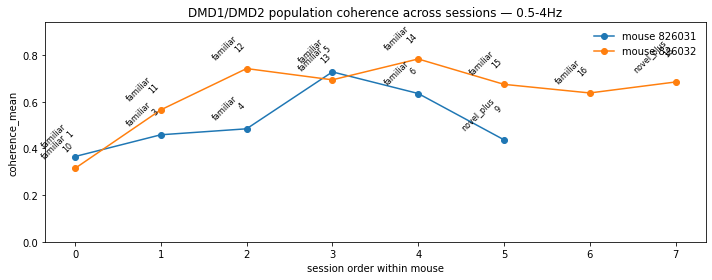

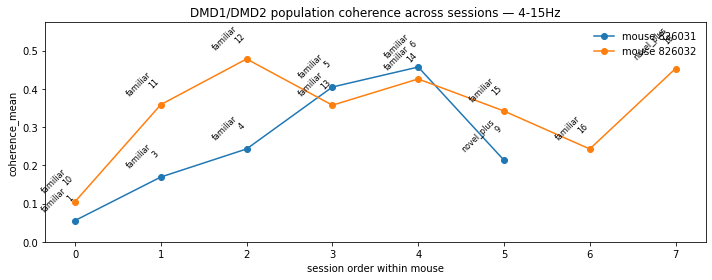

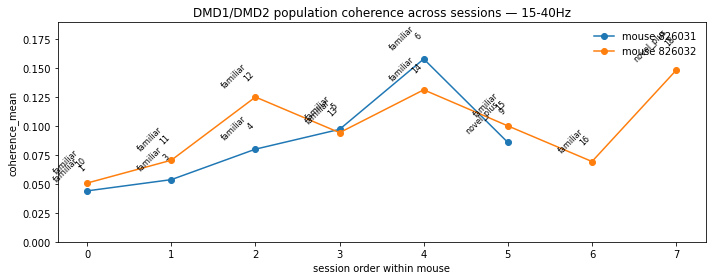

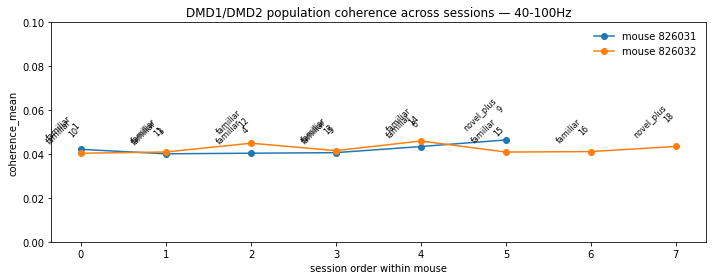

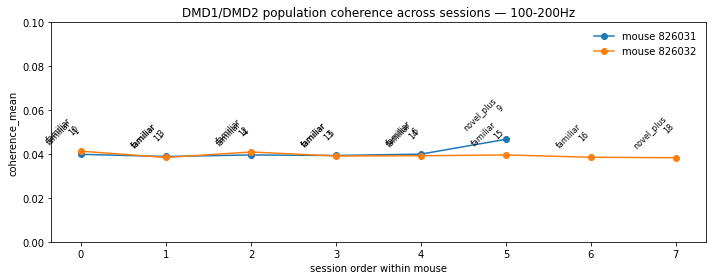

In [16]:
def plot_population_coherence_by_session(pop_band_df, value_col="coherence_mean"):
    if pop_band_df.empty:
        print("No population band data to plot.")
        return None

    bands = [b for b in COHERENCE_BANDS.keys() if b in set(pop_band_df["band"])]
    for band in bands:
        df = pop_band_df[pop_band_df["band"] == band].copy()
        df = df.sort_values(["mouse", "session_date", "asset_index"])
        fig, ax = plt.subplots(figsize=(10, 4))
        mice = sorted(df["mouse"].astype(str).unique())
        for mouse in mice:
            d = df[df["mouse"].astype(str) == mouse]
            x = np.arange(len(d))
            labels = [f"{st}\n{i}" for st, i in zip(d["session_type"].astype(str), d["asset_index"])]
            ax.plot(x, d[value_col], marker="o", lw=1.5, label=f"mouse {mouse}")
            for xx, yy, lab in zip(x, d[value_col], labels):
                ax.text(xx, yy, str(lab), fontsize=8, rotation=45, ha="right", va="bottom")
        ax.set_title(f"DMD1/DMD2 population coherence across sessions — {band}")
        ax.set_ylabel(value_col)
        ax.set_xlabel("session order within mouse")
        ax.set_ylim(bottom=0, top=min(1.05, max(0.1, np.nanmax(df[value_col]) * 1.2)))
        ax.legend(frameon=False)
        fig.tight_layout()
#         save_figure(fig, OUT_DIR, f"{today_str}_population_coherence_session_trajectory_{band}")

plot_population_coherence_by_session(pop_band_df, value_col="coherence_mean")

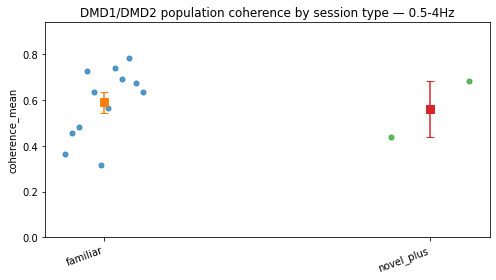

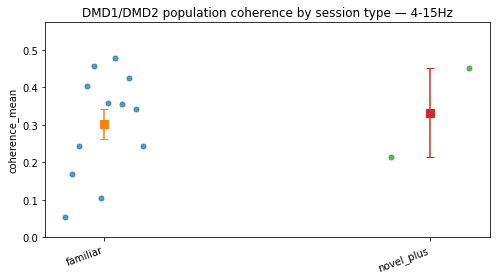

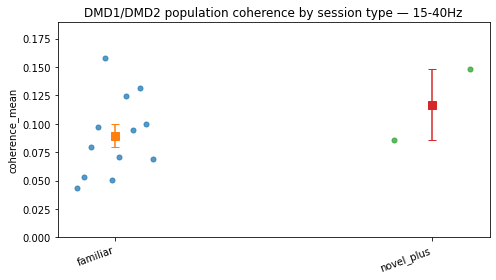

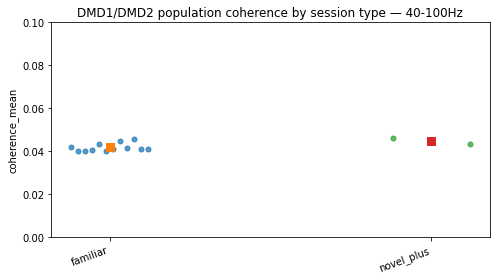

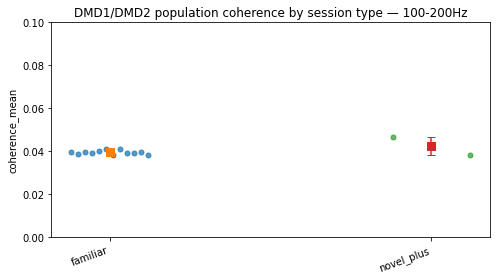

In [18]:
def plot_population_coherence_by_session_type(pop_band_df, value_col="coherence_mean"):
    if pop_band_df.empty:
        print("No population band data to plot.")
        return None

    bands = [b for b in COHERENCE_BANDS.keys() if b in set(pop_band_df["band"])]
    session_types = [s for s in SESSION_TYPE_ORDER if s in set(pop_band_df["session_type"].astype(str))]

    for band in bands:
        df = pop_band_df[pop_band_df["band"] == band].copy()
        fig, ax = plt.subplots(figsize=(7, 4))
        x_base = np.arange(len(session_types))

        # session-level points
        for i, st in enumerate(session_types):
            d = df[df["session_type"].astype(str) == st]
            y = d[value_col].to_numpy(dtype=float)
            jitter = np.linspace(-0.12, 0.12, len(y)) if len(y) > 1 else np.array([0.0])
            ax.plot(np.full(len(y), i) + jitter, y, "o", alpha=0.75, ms=5)
            if np.isfinite(y).sum():
                mean = np.nanmean(y)
                sem = np.nanstd(y, ddof=1) / np.sqrt(np.isfinite(y).sum()) if np.isfinite(y).sum() > 1 else 0
                ax.errorbar(i, mean, yerr=sem, fmt="s", ms=8, capsize=4)

        ax.set_xticks(x_base)
        ax.set_xticklabels(session_types, rotation=20, ha="right")
        ax.set_ylabel(value_col)
        ax.set_title(f"DMD1/DMD2 population coherence by session type — {band}")
        ax.set_ylim(bottom=0, top=min(1.05, max(0.1, np.nanmax(df[value_col]) * 1.2)))
        fig.tight_layout()
#         save_figure(fig, OUT_DIR, f"{today_str}_population_coherence_by_session_type_{band}")

plot_population_coherence_by_session_type(pop_band_df, value_col="coherence_mean")

## ROI-pair coherence: within-DMD versus between-DMD classes

In [19]:
def summarize_pair_coherence(pair_band_df):
    if pair_band_df.empty:
        print("No ROI-pair coherence data. Set RUN_ROI_PAIR_COHERENCE=True and rerun if needed.")
        return pd.DataFrame()
    summary = (
        pair_band_df
        .groupby(["mouse", "session_label", "session_type", "band", "pair_class"], observed=True)
        .agg(
            n_pairs=("coherence_mean", "size"),
            mean_pair_coherence=("coherence_mean", "mean"),
            median_pair_coherence=("coherence_mean", "median"),
            p95_pair_coherence=("coherence_mean", lambda x: np.nanpercentile(x, 95)),
        )
        .reset_index()
    )
    return summary

pair_summary_df = summarize_pair_coherence(pair_band_df)
display(pair_summary_df.head())

if len(pair_summary_df):
    out = OUT_DIR / f"{today_str}_asap7_roi_pair_coherence_session_summary.csv"
    pair_summary_df.to_csv(out, index=False)
    print("Saved:", out)

,mouse,session_label,session_type,band,pair_class,n_pairs,mean_pair_coherence,median_pair_coherence,p95_pair_coherence
0,826031,826031_2026-02-01_11-01-50,familiar,0.5-4Hz,between_DMDs,150,0.191831,0.162001,0.417660
1,826031,826031_2026-02-01_11-01-50,familiar,0.5-4Hz,within_DMD1,105,0.256779,0.223344,0.496789
2,826031,826031_2026-02-01_11-01-50,familiar,0.5-4Hz,within_DMD2,45,0.331938,0.338875,0.627357
3,826031,826031_2026-02-01_11-01-50,familiar,100-200Hz,between_DMDs,150,0.040508,0.040511,0.041171
4,826031,826031_2026-02-01_11-01-50,familiar,100-200Hz,within_DMD1,105,0.041653,0.041653,0.042716


Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence\2026-07-01_asap7_roi_pair_coherence_session_summary.csv


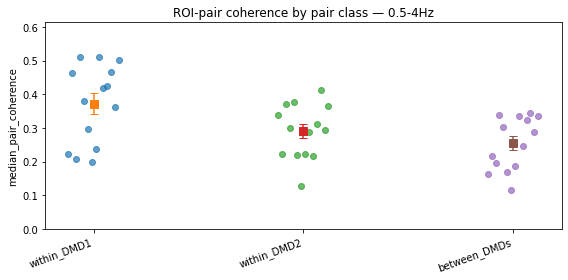

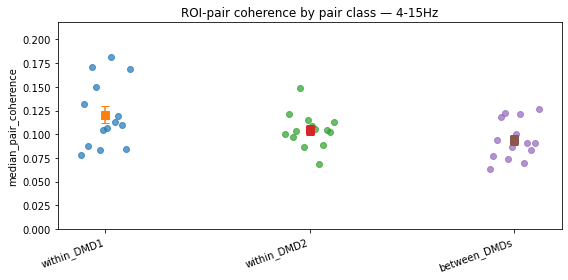

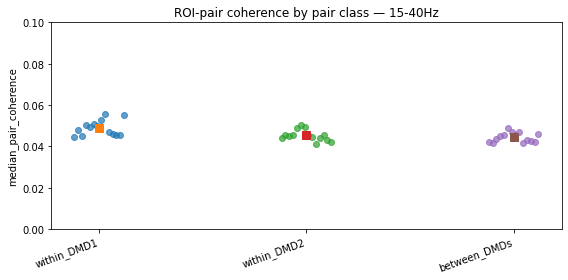

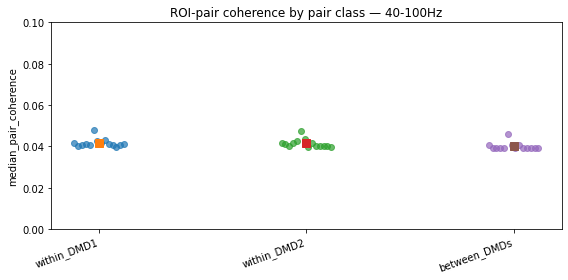

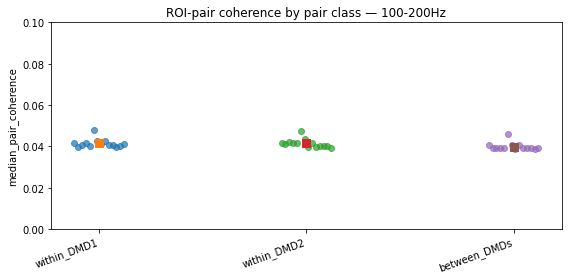

In [21]:
def plot_pair_class_coherence(pair_summary_df, value_col="median_pair_coherence"):
    if pair_summary_df.empty:
        return
    pair_classes = ["within_DMD1", "within_DMD2", "between_DMDs"]
    for band in [b for b in COHERENCE_BANDS.keys() if b in set(pair_summary_df["band"])] :
        df = pair_summary_df[pair_summary_df["band"] == band]
        fig, ax = plt.subplots(figsize=(8, 4))
        for i, cls in enumerate(pair_classes):
            d = df[df["pair_class"] == cls]
            y = d[value_col].to_numpy(dtype=float)
            jitter = np.linspace(-0.12, 0.12, len(y)) if len(y) > 1 else np.array([0.0])
            ax.plot(np.full(len(y), i) + jitter, y, "o", alpha=0.7)
            if np.isfinite(y).sum():
                mean = np.nanmean(y)
                sem = np.nanstd(y, ddof=1) / np.sqrt(np.isfinite(y).sum()) if np.isfinite(y).sum() > 1 else 0
                ax.errorbar(i, mean, yerr=sem, fmt="s", ms=8, capsize=4)
        ax.set_xticks(np.arange(len(pair_classes)))
        ax.set_xticklabels(pair_classes, rotation=20, ha="right")
        ax.set_ylabel(value_col)
        ax.set_title(f"ROI-pair coherence by pair class — {band}")
        ax.set_ylim(bottom=0, top=min(1.05, max(0.1, np.nanmax(df[value_col]) * 1.2)))
        fig.tight_layout()
#         save_figure(fig, OUT_DIR, f"{today_str}_roi_pair_coherence_by_class_{band}")

plot_pair_class_coherence(pair_summary_df, value_col="median_pair_coherence")

## Descriptive statistics for matched session types

In [22]:
def session_level_summary(df, value_col="coherence_mean"):
    if df.empty:
        return pd.DataFrame()
    out = (
        df
        .groupby(["band", "session_type"], observed=True)
        .agg(
            n_sessions=(value_col, "size"),
            n_mice=("mouse", "nunique"),
            mean=(value_col, "mean"),
            median=(value_col, "median"),
            sd=(value_col, "std"),
            sem=(value_col, lambda x: np.nanstd(x, ddof=1) / np.sqrt(np.isfinite(x).sum()) if np.isfinite(x).sum() > 1 else np.nan),
        )
        .reset_index()
    )
    return out

pop_stats = session_level_summary(pop_band_df, value_col="coherence_mean")
display(pop_stats)

if len(pop_stats):
    out = OUT_DIR / f"{today_str}_asap7_population_coherence_matched_session_type_stats.csv"
    pop_stats.to_csv(out, index=False)
    print("Saved:", out)

,band,session_type,n_sessions,n_mice,mean,median,sd,sem
0,0.5-4Hz,familiar,12,2,0.590054,0.636342,0.152901,0.044139
1,0.5-4Hz,novel_plus,2,2,0.560713,0.560713,0.175089,0.123806
2,100-200Hz,familiar,12,2,0.039564,0.039461,0.000869,0.000251
3,100-200Hz,novel_plus,2,2,0.042516,0.042516,0.005941,0.004201
4,15-40Hz,familiar,12,2,0.089410,0.087055,0.035123,0.010139
5,15-40Hz,novel_plus,2,2,0.116872,0.116872,0.044069,0.031162
6,4-15Hz,familiar,12,2,0.303198,0.349522,0.139105,0.040156
7,4-15Hz,novel_plus,2,2,0.333188,0.333188,0.169461,0.119827
8,40-100Hz,familiar,12,2,0.041869,0.041028,0.001906,0.000550
9,40-100Hz,novel_plus,2,2,0.044946,0.044946,0.002100,0.001485


Saved: C:\Users\andrew.shelton\Dropbox\allen institute\Documents\Presentations\OPhys\Lab_Meetings\2026-07-28_OPhys_LabMeetingV\figures\voltage_plots\asap7_cross_session_dmd_coherence\2026-07-01_asap7_population_coherence_matched_session_type_stats.csv


## Interpretation guardrails

For a first lab-meeting pass, treat the session as the unit of replication for DMD population coherence. ROI-pair summaries are useful descriptively, but pair counts are not independent biological replicates.

A coherence increase in 40–100 Hz or 100–200 Hz is interesting only if it survives the obvious QC checks: line-noise contamination, motion/running periods, DMD-specific optical SNR, and whether the effect is driven by a small number of sessions.